In [4]:
import numpy as np
import pandas as pd
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Try to import visualization libraries
try:
    import matplotlib.pyplot as plt
    import seaborn as sns
    HAS_VIZ = True
    plt.style.use('seaborn-v0_8-darkgrid')
    sns.set_palette("husl")
    print("✓ Visualization libraries loaded")
except ImportError:
    HAS_VIZ = False
    print("⚠ Warning: matplotlib/seaborn not available. Visualizations will be skipped.")

✓ Visualization libraries loaded


In [6]:
csv_path = Path("../data/processed/Barcelona_2014_2015_features.csv")
df = pd.read_csv(csv_path)

print(f"Loaded {len(df)} rows from {csv_path}")
print(f"Unique matches: {df['match_id'].nunique()}")
print(f"Unique players: {df['player_id'].nunique()}")
print(f"Columns: {len(df.columns)}")
print(f"\nFirst few rows:")
df.head()


Loaded 195 rows from ../data/processed/Barcelona_2014_2015_features.csv
Unique matches: 39
Unique players: 12
Columns: 75

First few rows:


,player_id,player_name,midfielder_type,match_id,team_id,team_name,season,computed_at,bypasses_per_match,possessions_involved,...,sliding_tackles,sliding_tackle_success_rate,ball_receipts_total,central_lane_receipts,one_touch_passes,weak_foot_pass_share,pressured_retention_rate,secondary_shot_assists,expected_assists,xg_chain
0,4320,Neymar da Silva Santos Junior,5,18242,217,Barcelona,2014/2015,2025-12-13T18:44:45.068090,52,60.0,...,3.0,NaN,61.0,6.0,20.0,0.20,0.98,3.0,NaN,0.95
1,5203,Sergio Busquets i Burgos,0,18242,217,Barcelona,2014/2015,2025-12-13T18:44:45.814253,52,59.0,...,2.0,0.5,53.0,14.0,14.0,0.15,1.00,0.0,NaN,0.81
2,5216,Andrés Iniesta Luján,1,18242,217,Barcelona,2014/2015,2025-12-13T18:44:46.559698,52,43.0,...,1.0,1.0,51.0,6.0,9.0,0.07,1.00,1.0,NaN,0.55
3,5470,Ivan Rakitić,1,18242,217,Barcelona,2014/2015,2025-12-13T18:44:47.304807,52,57.0,...,2.0,NaN,48.0,5.0,17.0,0.06,1.00,3.0,0.44,1.48
4,5503,Lionel Andrés Messi Cuccittini,4,18242,217,Barcelona,2014/2015,2025-12-13T18:44:48.044831,52,74.0,...,1.0,NaN,85.0,15.0,35.0,0.10,0.96,4.0,0.06,1.91


In [7]:
metadata_cols = ['match_id', 'team_id', 'team_name', 'season', 'bypasses_per_match']

# Feature columns (exclude metadata)
feature_cols = [c for c in df.columns if c not in metadata_cols and 
               c not in ['player_id', 'player_name', 'midfielder_type', 'computed_at']]

# Define aggregation strategy
# Counts/volumes: sum
count_features = [
    'possessions_involved', 'passes_attempted', 'progressive_passes',
    'final_third_entries_by_pass', 'key_passes', 'carries_attempted',
    'progressive_carries', 'successful_dribbles', 'carries_leading_to_shot',
    'carries_leading_to_key_pass', 'final_third_carries', 'penalty_area_carries',
    'pressures_applied', 'ball_recoveries', 'interceptions', 'tackles_won',
    'counterpress_actions', 'blocked_passes', 'blocked_shots',
    'clearance_followed_by_recovery', 'zone_entries', 'pressured_touches',
    'third_man_runs', 'wall_pass_events', 'shot_creating_actions',
    'fouls_committed', 'fouls_suffered', 'tactical_fouls', 'advantage_fouls_won',
    'set_piece_involvements', 'set_piece_duels_won', 'defensive_set_piece_clearances',
    'line_breaking_receipts', 'zone14_touches', 'penalty_area_deliveries',
    'switches_completed', 'aerial_duels_contested', 'fifty_fiftys_won',
    'sliding_tackles', 'ball_receipts_total', 'central_lane_receipts',
    'one_touch_passes', 'secondary_shot_assists', 'expected_assists'
]

# Rates/percentages: mean
rate_features = [
    'pass_completion_rate', 'under_pressure_pass_share', 'pressured_carry_success_rate',
    'press_to_interception_chain', 'pressure_to_self_recovery',
    'pressures_to_turnover_rate', 'pressured_touch_retention_rate',
    'corner_delivery_accuracy', 'cross_accuracy', 'aerial_duel_win_rate',
    'sliding_tackle_success_rate', 'weak_foot_pass_share',
    'pressured_retention_rate'
]

# Totals/distances: sum
total_features = [
    'possession_time_seconds', 'carry_distance_total', 'expected_threat_added',
    'xg_chain'
]

# Averages: mean
avg_features = [
    'tempo_index', 'average_position_x', 'average_position_y',
    'width_variance'
]

# Special: turnovers (sum)
special_features = ['turnovers']

print(f"Count features: {len(count_features)}")
print(f"Rate features: {len(rate_features)}")
print(f"Total features: {len(total_features)}")
print(f"Average features: {len(avg_features)}")


Count features: 44
Rate features: 13
Total features: 4
Average features: 4


In [8]:
agg_dict = {}

# Metadata: take first (same for all players in match)
for col in ['team_id', 'team_name', 'season', 'bypasses_per_match']:
    agg_dict[col] = 'first'

# Count features: sum
for col in count_features:
    if col in feature_cols:
        agg_dict[col] = 'sum'

# Rate features: mean
for col in rate_features:
    if col in feature_cols:
        agg_dict[col] = 'mean'

# Total features: sum
for col in total_features:
    if col in feature_cols:
        agg_dict[col] = 'sum'

# Average features: mean
for col in avg_features:
    if col in feature_cols:
        agg_dict[col] = 'mean'

# Special features
for col in special_features:
    if col in feature_cols:
        agg_dict[col] = 'sum'

# Handle any remaining features with mean
for col in feature_cols:
    if col not in agg_dict:
        agg_dict[col] = 'mean'

# Group by match and aggregate
match_df = df.groupby('match_id').agg(agg_dict).reset_index()

# Add number of midfielders per match
midfielder_counts = df.groupby('match_id')['player_id'].count().reset_index()
midfielder_counts.columns = ['match_id', 'num_midfielders']
match_df = match_df.merge(midfielder_counts, on='match_id')

print(f"Aggregated to {len(match_df)} matches")
print(f"Match-level features shape: {match_df.shape}")
print(f"\nFirst few rows:")
match_df.head()

Aggregated to 39 matches
Match-level features shape: (39, 72)

First few rows:


,match_id,team_id,team_name,season,bypasses_per_match,possessions_involved,passes_attempted,progressive_passes,final_third_entries_by_pass,key_passes,...,possession_time_seconds,carry_distance_total,expected_threat_added,xg_chain,tempo_index,average_position_x,average_position_y,width_variance,turnovers,num_midfielders
0,18242,217,Barcelona,2014/2015,52,293.0,294.0,71.0,115.0,6.0,...,1550.54,808.99,0.0,5.70,22.390,72.198,38.616,278.428,19.0,5
1,70264,217,Barcelona,2014/2015,45,326.0,347.0,84.0,135.0,4.0,...,1772.06,552.59,0.0,4.97,22.854,72.828,42.200,211.614,16.0,5
2,70273,217,Barcelona,2014/2015,49,326.0,292.0,84.0,104.0,5.0,...,1294.05,547.97,0.0,5.88,26.346,68.950,43.290,369.500,7.0,5
3,70303,217,Barcelona,2014/2015,54,317.0,304.0,71.0,110.0,6.0,...,1604.24,941.02,0.0,9.62,23.168,68.646,40.022,250.234,7.0,5
4,265835,217,Barcelona,2014/2015,47,351.0,375.0,91.0,147.0,5.0,...,1938.41,943.63,0.0,6.64,22.312,73.530,39.882,234.372,14.0,5


In [9]:
print("="*80)
print("BASIC STATISTICS")
print("="*80)

print(f"\nNumber of matches: {len(match_df)}")
print(f"\nBypasses per match:")
print(match_df['bypasses_per_match'].describe())

print(f"\nNumber of midfielders per match:")
print(match_df['num_midfielders'].describe())

print(f"\nBypasses distribution:")
print(f"  Mean: {match_df['bypasses_per_match'].mean():.2f}")
print(f"  Std: {match_df['bypasses_per_match'].std():.2f}")
print(f"  Min: {match_df['bypasses_per_match'].min()}")
print(f"  Max: {match_df['bypasses_per_match'].max()}")
print(f"  Median: {match_df['bypasses_per_match'].median():.2f}")
print(f"  Q1: {match_df['bypasses_per_match'].quantile(0.25):.2f}")
print(f"  Q3: {match_df['bypasses_per_match'].quantile(0.75):.2f}")

BASIC STATISTICS

Number of matches: 39

Bypasses per match:
count    39.000000
mean     49.794872
std       6.018303
min      33.000000
25%      45.000000
50%      50.000000
75%      53.500000
max      65.000000
Name: bypasses_per_match, dtype: float64

Number of midfielders per match:
count    39.0
mean      5.0
std       0.0
min       5.0
25%       5.0
50%       5.0
75%       5.0
max       5.0
Name: num_midfielders, dtype: float64

Bypasses distribution:
  Mean: 49.79
  Std: 6.02
  Min: 33
  Max: 65
  Median: 50.00
  Q1: 45.00
  Q3: 53.50


In [10]:
print("="*80)
print("CORRELATION ANALYSIS")
print("="*80)

# Select numeric feature columns (exclude metadata)
feature_cols_for_corr = [c for c in match_df.columns 
                        if c not in ['match_id', 'team_id', 'team_name', 'season', 
                                    'num_midfielders', 'bypasses_per_match']]

# Calculate correlations with bypasses
correlations = {}
for col in feature_cols_for_corr:
    if match_df[col].dtype in [np.float64, np.int64, np.float32, np.int32]:
        corr = match_df[col].corr(match_df['bypasses_per_match'])
        if not np.isnan(corr):
            correlations[col] = corr

# Sort by absolute correlation
sorted_corrs = sorted(correlations.items(), key=lambda x: abs(x[1]), reverse=True)

print(f"\nTotal features analyzed: {len(correlations)}")
print(f"\nTop 20 features most correlated with bypasses_per_match:")
print(f"{'Feature':<40} {'Correlation':>12}")
print("-" * 54)
for feature, corr in sorted_corrs[:20]:
    print(f"{feature:<40} {corr:>12.4f}")

print(f"\nTop 10 positive correlations:")
positive_corrs = [(f, c) for f, c in sorted_corrs if c > 0][:10]
for feature, corr in positive_corrs:
    print(f"  {feature:<40} {corr:>12.4f}")

print(f"\nTop 10 negative correlations:")
negative_corrs = [(f, c) for f, c in sorted_corrs if c < 0][:10]
for feature, corr in negative_corrs:
    print(f"  {feature:<40} {corr:>12.4f}")


CORRELATION ANALYSIS

Total features analyzed: 64

Top 20 features most correlated with bypasses_per_match:
Feature                                   Correlation
------------------------------------------------------
pass_completion_rate                          -0.4953
final_third_entries_by_pass                   -0.4253
passes_attempted                              -0.4078
one_touch_passes                              -0.4076
average_position_x                            -0.4033
ball_receipts_total                           -0.4025
counterpress_actions                           0.3972
pressures_applied                              0.3876
zone14_touches                                -0.3773
possession_time_seconds                       -0.3742
aerial_duels_contested                         0.3508
expected_assists                               0.3000
penalty_area_carries                          -0.2833
set_piece_duels_won                            0.2819
fouls_committed            

In [11]:
print("="*80)
print("FEATURE CATEGORY ANALYSIS")
print("="*80)

categories = {
    'Possession & Tempo': ['possessions_involved', 'possession_time_seconds', 'tempo_index', 'turnovers'],
    'Passing': ['passes_attempted', 'pass_completion_rate', 'progressive_passes', 
               'final_third_entries_by_pass', 'key_passes', 'under_pressure_pass_share'],
    'Carrying': ['carries_attempted', 'progressive_carries', 'carry_distance_total',
                'successful_dribbles', 'final_third_carries', 'penalty_area_carries'],
    'Defensive Actions': ['pressures_applied', 'ball_recoveries', 'interceptions',
                        'tackles_won', 'blocked_passes', 'blocked_shots'],
    'Pressure & Recovery': ['press_to_interception_chain', 'counterpress_actions',
                          'pressure_to_self_recovery', 'pressures_to_turnover_rate'],
    'Spatial': ['average_position_x', 'average_position_y', 'width_variance', 'zone_entries'],
    'Attacking Creation': ['shot_creating_actions', 'expected_threat_added',
                        'secondary_shot_assists', 'expected_assists', 'xg_chain'],
    'Set Pieces': ['set_piece_involvements', 'corner_delivery_accuracy',
                  'set_piece_duels_won', 'defensive_set_piece_clearances'],
    'Progression': ['line_breaking_receipts', 'zone14_touches', 'penalty_area_deliveries',
                   'switches_completed', 'cross_accuracy'],
    'Duels': ['aerial_duels_contested', 'aerial_duel_win_rate', 'fifty_fiftys_won',
             'sliding_tackles', 'sliding_tackle_success_rate'],
    'Receiving': ['ball_receipts_total', 'central_lane_receipts', 'one_touch_passes',
                 'weak_foot_pass_share'],
    'Discipline': ['fouls_committed', 'fouls_suffered', 'tactical_fouls', 'advantage_fouls_won']
}

category_corrs = {}
for category, features in categories.items():
    cat_corrs = []
    for feat in features:
        if feat in correlations:
            cat_corrs.append(abs(correlations[feat]))
    if cat_corrs:
        category_corrs[category] = {
            'mean_abs_corr': np.mean(cat_corrs),
            'max_abs_corr': np.max(cat_corrs),
            'features': len(cat_corrs)
        }

print(f"\n{'Category':<30} {'Mean |Corr|':>12} {'Max |Corr|':>12} {'Features':>10}")
print("-" * 66)
for cat, stats in sorted(category_corrs.items(), key=lambda x: x[1]['mean_abs_corr'], reverse=True):
    print(f"{cat:<30} {stats['mean_abs_corr']:>12.4f} {stats['max_abs_corr']:>12.4f} {stats['features']:>10}")


FEATURE CATEGORY ANALYSIS

Category                        Mean |Corr|   Max |Corr|   Features
------------------------------------------------------------------
Passing                              0.2967       0.4953          6
Receiving                            0.2731       0.4076          4
Progression                          0.2549       0.3773          5
Pressure & Recovery                  0.2175       0.3972          4
Possession & Tempo                   0.2136       0.3742          4
Carrying                             0.2023       0.2833          6
Duels                                0.2012       0.3508          4
Spatial                              0.1989       0.4033          4
Defensive Actions                    0.1756       0.3876          6
Set Pieces                           0.1594       0.2819          4
Attacking Creation                   0.1526       0.3000          4
Discipline                           0.1266       0.2795          4


In [12]:
print("="*80)
print("HIGH vs LOW BYPASS MATCH COMPARISON")
print("="*80)

median_bypasses = match_df['bypasses_per_match'].median()
high_bypass = match_df[match_df['bypasses_per_match'] >= median_bypasses]
low_bypass = match_df[match_df['bypasses_per_match'] < median_bypasses]

print(f"\nMedian bypasses: {median_bypasses:.0f}")
print(f"High bypass matches (>= {median_bypasses:.0f}): {len(high_bypass)} matches")
print(f"Low bypass matches (< {median_bypasses:.0f}): {len(low_bypass)} matches")

# Compare key features between high and low bypass matches
key_features = [
    'passes_attempted', 'pass_completion_rate', 'progressive_passes',
    'carries_attempted', 'pressures_applied', 'ball_recoveries',
    'interceptions', 'possession_time_seconds', 'tempo_index',
    'shot_creating_actions', 'zone_entries'
]

print(f"\n{'Feature':<30} {'High Bypass':>15} {'Low Bypass':>15} {'Difference':>12}")
print("-" * 72)
for feat in key_features:
    if feat in match_df.columns:
        high_mean = high_bypass[feat].mean()
        low_mean = low_bypass[feat].mean()
        diff = high_mean - low_mean
        print(f"{feat:<30} {high_mean:>15.2f} {low_mean:>15.2f} {diff:>12.2f}")


HIGH vs LOW BYPASS MATCH COMPARISON

Median bypasses: 50
High bypass matches (>= 50): 20 matches
Low bypass matches (< 50): 19 matches

Feature                            High Bypass      Low Bypass   Difference
------------------------------------------------------------------------
passes_attempted                        297.60          335.05       -37.45
pass_completion_rate                      0.84            0.88        -0.03
progressive_passes                       75.40           76.21        -0.81
carries_attempted                        49.65           48.63         1.02
pressures_applied                        68.05           52.21        15.84
ball_recoveries                          21.40           20.68         0.72
interceptions                             2.90            2.05         0.85
possession_time_seconds                1636.08         1896.91      -260.83
tempo_index                              21.72           21.37         0.35
shot_creating_actions          

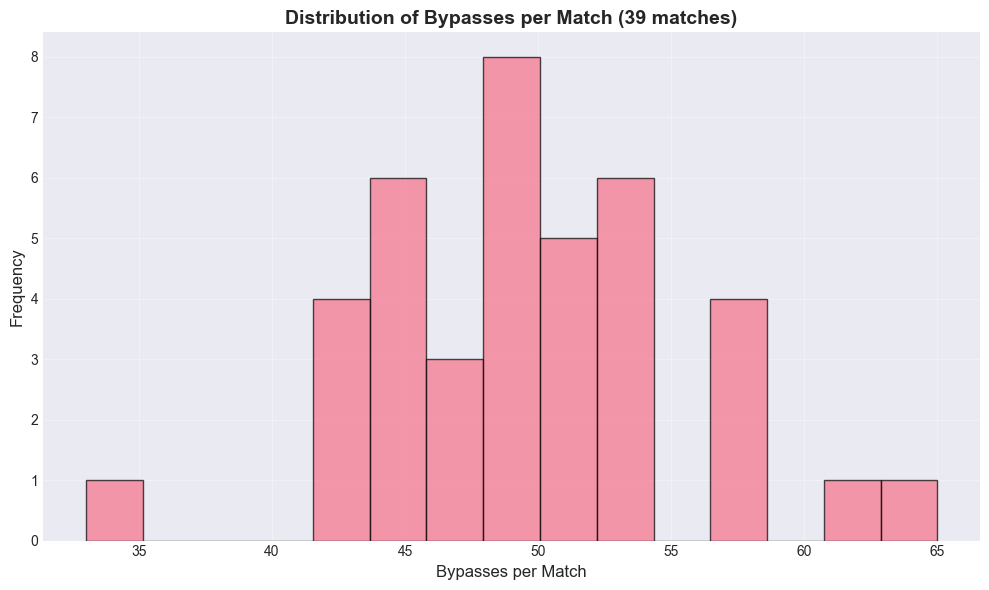

In [13]:
if HAS_VIZ:
    plt.figure(figsize=(10, 6))
    plt.hist(match_df['bypasses_per_match'], bins=15, edgecolor='black', alpha=0.7)
    plt.xlabel('Bypasses per Match', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.title('Distribution of Bypasses per Match (39 matches)', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Skipping visualization (matplotlib not available)")

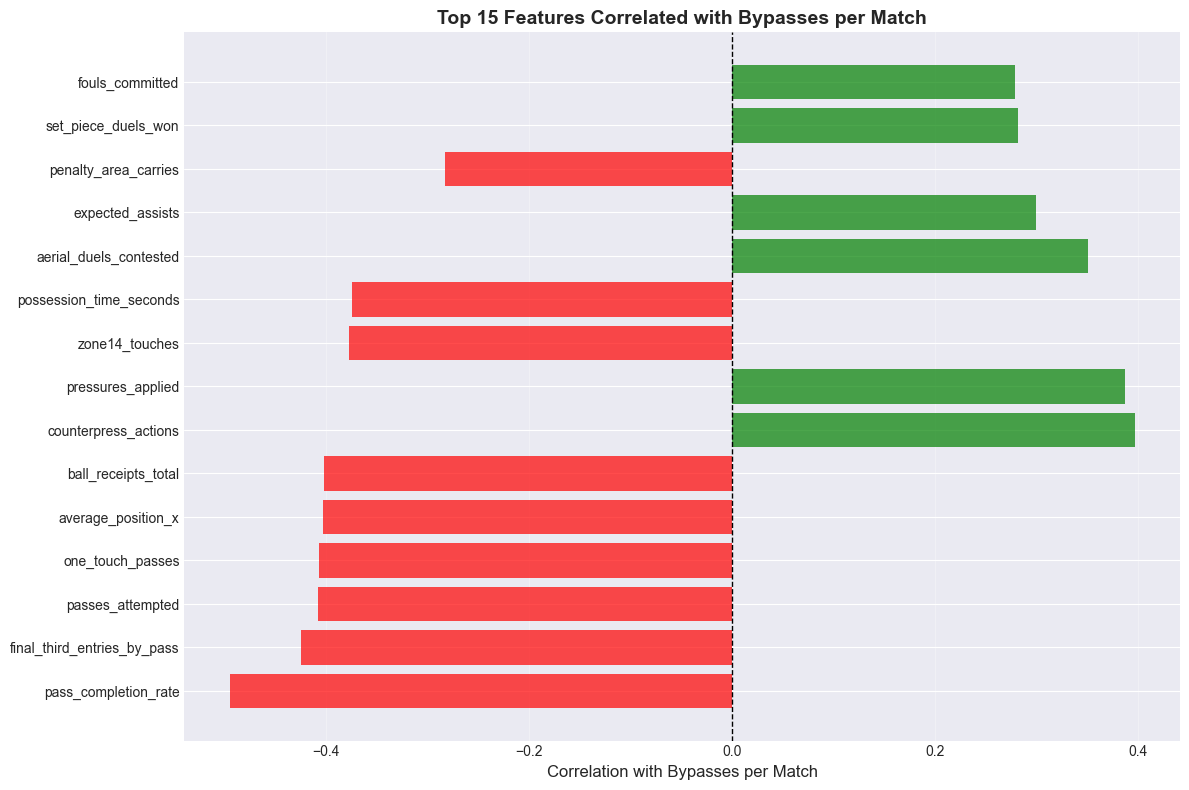

In [14]:
if HAS_VIZ:
    sorted_corrs = sorted(correlations.items(), key=lambda x: abs(x[1]), reverse=True)[:15]
    features = [f[0] for f in sorted_corrs]
    corr_values = [f[1] for f in sorted_corrs]
    
    plt.figure(figsize=(12, 8))
    colors = ['red' if c < 0 else 'green' for c in corr_values]
    plt.barh(range(len(features)), corr_values, color=colors, alpha=0.7)
    plt.yticks(range(len(features)), features)
    plt.xlabel('Correlation with Bypasses per Match', fontsize=12)
    plt.title('Top 15 Features Correlated with Bypasses per Match', fontsize=14, fontweight='bold')
    plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
    plt.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()
else:
    print("Skipping visualization (matplotlib not available)")



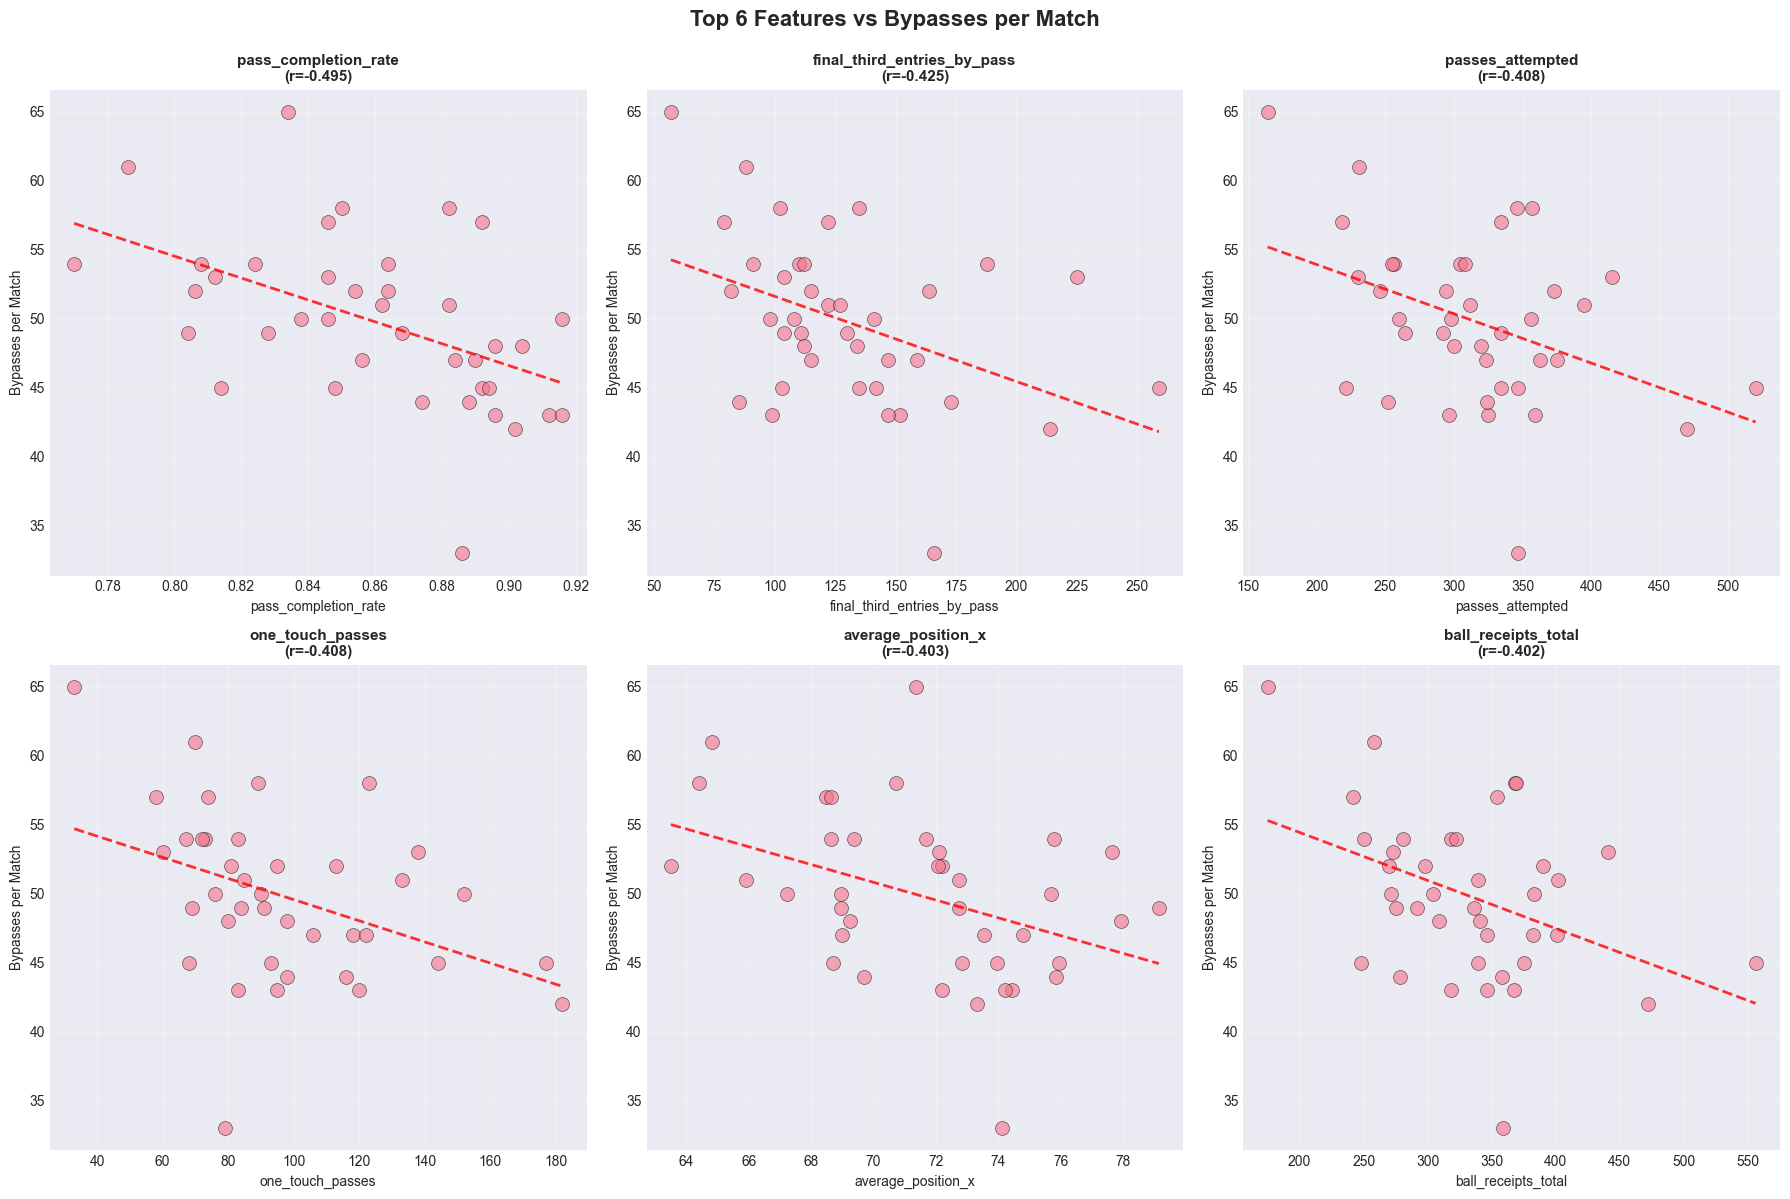

In [15]:
if HAS_VIZ:
    top_features = [f[0] for f in sorted(correlations.items(), key=lambda x: abs(x[1]), reverse=True)[:6]]
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()
    
    for idx, feat in enumerate(top_features):
        if feat in match_df.columns:
            axes[idx].scatter(match_df[feat], match_df['bypasses_per_match'], 
                            alpha=0.6, s=100, edgecolors='black', linewidth=0.5)
            axes[idx].set_xlabel(feat, fontsize=10)
            axes[idx].set_ylabel('Bypasses per Match', fontsize=10)
            axes[idx].set_title(f'{feat}\n(r={correlations[feat]:.3f})', fontsize=11, fontweight='bold')
            axes[idx].grid(True, alpha=0.3)
            
            # Add trend line
            z = np.polyfit(match_df[feat].dropna(), 
                          match_df.loc[match_df[feat].notna(), 'bypasses_per_match'], 1)
            p = np.poly1d(z)
            x_line = np.linspace(match_df[feat].min(), match_df[feat].max(), 100)
            axes[idx].plot(x_line, p(x_line), "r--", alpha=0.8, linewidth=2)
    
    plt.suptitle('Top 6 Features vs Bypasses per Match', fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.show()
else:
    print("Skipping visualization (matplotlib not available)")


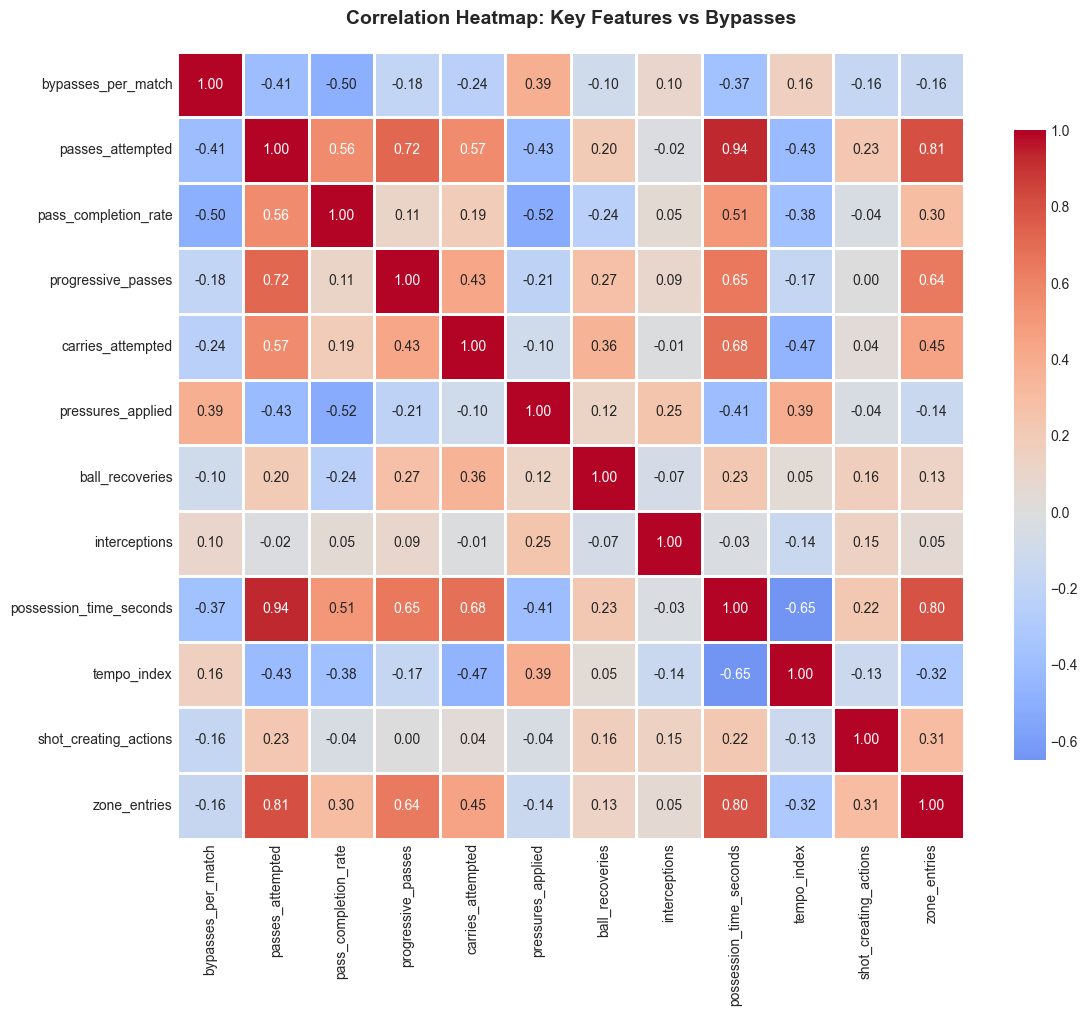

In [16]:
if HAS_VIZ:
    key_features = [
        'bypasses_per_match', 'passes_attempted', 'pass_completion_rate',
        'progressive_passes', 'carries_attempted', 'pressures_applied',
        'ball_recoveries', 'interceptions', 'possession_time_seconds',
        'tempo_index', 'shot_creating_actions', 'zone_entries'
    ]
    
    available_features = [f for f in key_features if f in match_df.columns]
    corr_matrix = match_df[available_features].corr()
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                square=True, linewidths=1, cbar_kws={"shrink": 0.8})
    plt.title('Correlation Heatmap: Key Features vs Bypasses', fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()
else:
    print("Skipping visualization (matplotlib not available)")

In [17]:
output_dir = Path("data/explain/match_level_eda")
output_dir.mkdir(parents=True, exist_ok=True)
output_csv = output_dir / "match_level_features.csv"
match_df.to_csv(output_csv, index=False)
print(f"Saved aggregated match data to: {output_csv}")
print(f"Shape: {match_df.shape}")


Saved aggregated match data to: data/explain/match_level_eda/match_level_features.csv
Shape: (39, 72)


In [18]:
print("="*80)
print("MATCH-BY-MATCH BREAKDOWN")
print("="*80)

# Show matches with highest and lowest bypasses
print("\nTop 5 matches with highest bypasses:")
top_matches = match_df.nlargest(5, 'bypasses_per_match')[['match_id', 'bypasses_per_match', 'num_midfielders']]
print(top_matches.to_string(index=False))

print("\nTop 5 matches with lowest bypasses:")
bottom_matches = match_df.nsmallest(5, 'bypasses_per_match')[['match_id', 'bypasses_per_match', 'num_midfielders']]
print(bottom_matches.to_string(index=False))


MATCH-BY-MATCH BREAKDOWN

Top 5 matches with highest bypasses:
 match_id  bypasses_per_match  num_midfielders
   267499                  65                5
   267343                  61                5
   266525                  58                5
   266967                  58                5
   266631                  57                5

Top 5 matches with lowest bypasses:
 match_id  bypasses_per_match  num_midfielders
   267400                  33                5
   266320                  42                5
   265896                  43                5
   265963                  43                5
   266921                  43                5


In [19]:
print("="*80)
print("SUMMARY STATISTICS TABLE")
print("="*80)

# Create summary table for key features
summary_features = [
    'bypasses_per_match', 'num_midfielders', 'passes_attempted', 
    'pass_completion_rate', 'progressive_passes', 'carries_attempted',
    'pressures_applied', 'ball_recoveries', 'interceptions',
    'possession_time_seconds', 'tempo_index', 'shot_creating_actions'
]

summary_df = match_df[summary_features].describe()
print("\nSummary statistics for key features:")
print(summary_df.round(2))


SUMMARY STATISTICS TABLE

Summary statistics for key features:
       bypasses_per_match  num_midfielders  passes_attempted  \
count               39.00             39.0             39.00   
mean                49.79              5.0            315.85   
std                  6.02              0.0             68.87   
min                 33.00              5.0            164.00   
25%                 45.00              5.0            262.00   
50%                 50.00              5.0            320.00   
75%                 53.50              5.0            351.50   
max                 65.00              5.0            520.00   

       pass_completion_rate  progressive_passes  carries_attempted  \
count                 39.00               39.00              39.00   
mean                   0.86               75.79              49.15   
std                    0.04               16.86              15.82   
min                    0.77               35.00              22.00   
25%       